# T023 · What is a kinase?

**Note:** This talktorial is a part of TeachOpenCADD, a platform that aims to teach domain-specific skills and to provide pipeline templates as starting points for research projects.

Authors:

- Dominique Sydow, 2021, [Volkamer lab, Charité](https://volkamerlab.org/)
- Talia B. Kimber, 2021, [Volkamer lab, Charité](https://volkamerlab.org/)
- Andrea Volkamer, 2021, [Volkamer lab, Charité](https://volkamerlab.org/)

## Aim of this talktorial

In this talktorial, we will talk about kinases: why are they important in life and drug design, what do they look like, and what data resources are available?
Finally, we select a set of kinases which will be analyzed in the forthcoming talktorials **T024**-**T028** with respect to their similarity, the goal being to gain insight into potential off-target effects.

### Contents in *Theory*

- Kinases in a nutshell
    - The human kinome
    - Kinase structures and important motifs
- Kinase resources
    - Kinase structures and related information
    - Bioactivity data
- Kinase similarity: Off-targets and promiscuous binding
- Kinase dataset compilation

### Contents in *Practical*

- Define the kinases of interest

### References

- Kinases as drug targets: [<i>Nat. Rev. Drug Discov.</i> (2021), <b>20(7)</b>, 551-569](https://doi.org/10.1038/s41573-021-00195-4)
- Sequence-based kinase clustering: Manning et al. [<i>Science</i> (2002), <b>298(5600)</b>, 1912-1934](https://doi.org/10.1126/science.1075762)
- KinMap: 
  - Paper: [<i>BMC Bioinformatics</i> (2017), <b>18</b>, 16](https://dx.doi.org/10.1186%2Fs12859-016-1433-7)
  - Website: http://www.kinhub.org/kinmap/
- KLIFS
  - KLIFS URL: https://klifs.net/
  - KLIFS database: [<i>Nucleic Acid Res.</i> (2020), <b>49(D1)</b>, D562-D569](https://doi.org/10.1093/nar/gkaa895)
  - KLIFS binding site definition: [<i>J. Med. Chem.</i> (2014), <b>57(2)</b>, 249-277](https://doi.org/10.1021/jm400378w)
- Bioactivity data
  - Karaman et al. dataset: [<i>Nature Biotechnology</i> (2008), <b>26</b>, 127-132](https://doi.org/10.1038/nbt1358)
  - Davis et al. dataset: [<i>Nature Biotechnology</i> (2011), <b>29</b>, 1046-1051](https://doi.org/10.1038/nbt.1990)
  - KIBA dataset: [<i>J. Chem. Inf. Model.</i> (2014), <b>54(3)</b>, 753-743](https://doi.org/10.1021/ci400709d)
  - PKIS dataset: [<i>PLOS ONE</i> (2017), <b>12</b>, 1-20](https://doi.org/10.1371/journal.pone.0181585)
- Kinase selection: [<i>Molecules</i> (2021), <b>26(3)</b>, 629](https://www.mdpi.com/1420-3049/26/3/629)

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 23
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## Theory

### Kinases in a nutshell

Kinases are established drug targets to combat cancer and inflammatory diseases ([<i>Nat. Rev. Drug Discov.</i> (2021), <b>20(7)</b>, 551-569](https://doi.org/10.1038/s41573-021-00195-4)). They are involved in most aspects of cell life by phosphorylating, and thereby activating, either themselves or other proteins. They are among the most frequently mutated proteins in tumors.

As of September 2021, $5782$ X-ray structures of human kinases have been resolved (see the [KLIFS](https://klifs.net/) database) and $67$ FDA-approved small molecule protein kinase inhibitors are on the market (see [the list](https://brimr.org/protein-kinase-inhibitors/) compiled by the Blue Ridge Institute for Medical Research). Most of the approved drugs bind in the ATP-binding pocket and intermediate surroundings.

Despite of decades of kinase research, there are still many open challenges:

- A large fraction of the kinome is un-/underexplored.
- Many kinase inhibitors are promiscuous binders causing off-target effects or enabling polypharmacology.
- There are occurrences of drug resistance due to mutations.

#### The human kinome 

The human kinome consists of over $500$ protein kinases, but this number may vary depending on the data resource (see [overview on Kinodata](https://github.com/openkinome/kinodata/blob/master/human-kinases/human_kinases.ipynb)).

As reported in [<i>Science</i> (2002), <b>298(5600)</b>, 1912-1934](https://doi.org/10.1126/science.1075762), Manning _et al._ clustered the human protein kinases based on their sequence similarity into eight major groups (AGC, CAMK, CK1, CMGC, RGC, STE, TK, TKL) and one "Other" group for unassigned kinases, as well as atypical kinases. The kinase clustering is visualized as the Manning kinome tree. The kinase resource [KinMap](http://www.kinhub.org/kinmap/) enables mapping of kinase data onto that tree, e.g. the number of X-ray structures per kinase as shown in Figure 1.

![Manning tree with number of structures per kinase (KinMap)](images/kinmap_n_structures_per_kinase.png)

*Figure 1:* 
Number of PDB structures per kinase mapped onto the Manning kinome tree using [KinMap](http://www.kinhub.org/kinmap/). Check the appendix on how to generate this KinMap tree.
<!---
We are using KLIFS kinase names; some are not recognized by KinMap and were simply dropped!
--->

#### Kinase structures and important motifs

Kinase sequences and structures are highly conserved. Important regions in the kinase pocket include (see Figure 2):

- Hinge region: Forms key hydrogen bonds to ligands.
- DFG motif: Flips between phenylalanine (F) and aspartate (D), driving the active and inactive state.
- αC-helix: Forms in the αC-in conformation a salt bridge between highly conserved lysine (K) and glutamine (Q).
- Glycine-rich (G-rich) loop: Stabilizes ATP binding.

![Kinase structure with key motifs](images/T023_kinase_structure.png)

*Figure 2:* 
Kinase structure with important key motifs: Hinge region, DFG motif, αC-helix, and G-rich loop. The example structure shown here represents CDK2, PDB ID: [1FIN](https://www.rcsb.org/structure/1fin). Check the appendix on how to generate this visualization with `opencadd`.

### Kinase resources

The focus on this protein family has led to a plethora of freely available data on compounds, bioactivity, and structures that are being used for computational drug development ([<i>Annual Reports in Medicinal Chemistry</i> 50 (2017): 197-236](https://doi.org/10.1016/bs.armc.2017.08.001)).

#### Kinase structures and related information: KLIFS

The KLIFS database ([<i>Nucleic Acid Res.</i> (2020), <b>49(D1)</b>, D562-D569](https://doi.org/10.1093/nar/gkaa895), [<i>J. Med. Chem.</i> (2014), <b>57(2)</b>, 249-277](https://doi.org/10.1021/jm400378w)) fetches all kinase structures deposited in the structural database PDB ([<i>Acta Cryst.</i> (2002), <b>D58</b>, 899-907](https://doi.org/10.1107/S0907444902003451), [<i>Structure</i> (2012), <b>20(3)</b>, 391-396](https://doi.org/10.1016/j.str.2012.01.010)) and processes them as follows: All multi-chain structures in the PDB are split into monomers and aligned to each other with a special focus on a pre-defined binding site of $85$ residues (Figure 3). For example, this means that the conserved gatekeeper (GK) residue at KLIFS position $45$ can be easily queried for any of the over $10,000$ monomeric kinase structures in KLIFS. 

![KLIFS binding site](https://klifs.net/images/faq/colors.png)

*Figure 3:* 
Kinase binding site residues as defined by KLIFS.
Figure and description taken from: [<i>J. Med. Chem.</i> (2014), <b>57(2)</b>, 249-277](https://doi.org/10.1021/jm400378w).

Each structure, kinase, and ligand in KLIFS is associated with an identifier (we will use those at times in the downstream talktorials):

- Structure KLIFS ID
- Kinase KLIFS ID
- Ligand KLIFS ID

KLIFS contains not only kinase structures and their pocket definitions (used in __Talktorials T024 and T025__) but also a lot of structure-, kinase-, and/or ligand-associated data:

- Interaction fingerprints (used in __Talktorial T026__)
- Structure conformations
- Bioactivity data from ChEMBL
- Approved drugs
- Subpocket coverage by co-crystallized ligands

#### Bioactivity data

[ChEMBL](https://www.ebi.ac.uk/chembl/) is a well-known bioactivity database, which releases updated versions every now and then.
In September 2021, there are over two million compounds and $14,000$ targets that are stored. In ChEMBL29, there are over $160,000$ measurements on kinases (see Figure 4).

- `kinodata` GitHub repository: https://github.com/openkinome/kinodata
- `kinodata` ChEMBL29 release: https://github.com/openkinome/kinodata/releases/tag/v0.3 (`activities-chembl29_v0.3.zip`)

As with other data types, the coverage of bioactivity data is highly unbalanced among the human kinases, depending on how much research is spent on certain kinases.

![Manning tree with number of ChEMBL activities per kinase (KinMap)](images/kinmap_n_activities_per_kinase.png)

*Figure 4:* 
Number of ChEMBL29 bioactivities per kinase mapped onto the Manning kinome tree using KinMap. Check the appendix on how to generate this KinMap tree.
<!---
We are using KLIFS kinase names; some are not recognized by KinMap and were simply dropped!
--->

However, ChEMBL is not the only available bioactivity database. Below is an non-exhaustive list of available kinase profiling data sets.


- Karaman _et al._ dataset
  - Paper: [<i>Nature Biotechnology</i> (2008), <b>26</b>, 127-132](https://doi.org/10.1038/nbt1358)
  - Data: [KinMap data (JSON)](http://kinhub.org/js/Davis_profiling.js)
- Davis _et al._ dataset
  - Paper: [<i>Nature Biotechnology</i> (2011), <b>29</b>, 1046-1051](https://doi.org/10.1038/nbt.1990)
  - Data: [KinMap data (JSON)](http://kinhub.org/js/Karaman_profiling.js)
- KIBA dataset
  - Paper: [<i>J. Chem. Inf. Model.</i> (2014), <b>54(3)</b>, 753-743](https://doi.org/10.1021/ci400709d)
  - Data: [SI data (XLSX)](https://ndownloader.figstatic.com/files/3950161)
- PKIS dataset
  - Paper: [<i>PLOS ONE</i> (2017), <b>12</b>, 1-20](https://doi.org/10.1371/journal.pone.0181585)
  - Data: [SI data (XLSX)](https://doi.org/10.1371/journal.pone.0181585.s004)

### Kinase similarity: Off-targets and promiscuous binding

As described before, kinases are highly conserved, especially in their binding site. This high similarity is a challenge in drug design because ligands may form similar binding modes not only with their designated target (on-target) but also with other targets (off-targets). Such promiscuous binding can cause mild to severe side effects.

Predicting these side effects is non-trivial since some off-targets are not obvious. For example, the EGFR inhibitor Erlotinib shows affinities to other kinases in the highly sequentially-similar TK kinase group. However, it also strongly affects the off-targets GAK, LOK, and SLK, which are in more remote kinase groups (Figure 5). 

![Erlotinib profiling data from Karaman dataset (KinMap)](images/kinmap_erlotinib_karaman.png)

*Figure 5:* 
Profiling data for EGFR inhibitor Erlobinib from the Karaman _et al._ dataset ([<i>Nature Biotechnology</i> (2008), <b>26</b>, 127-132](https://doi.org/10.1038/nbt1358)) mapped onto the Manning kinome tree using [KinMap](http://www.kinhub.org/kinmap/). Check the appendix of this notebook on how to generate this figure.

In the following four talktorials, namely __Talktorials T024-027__, we will assess kinase similarity from different perspectives, which we compare with each other in __Talktorial T028__:

- __Talktorial T024__: Kinase similarity based on KLIFS pocket sequence
- __Talktorial T025__: Kinase similarity based on KiSSim pocket structure
- __Talktorial T026__: Kinase similarity based on KLIFS interaction fingerprint
- __Talktorial T027__: Kinase similarity based on ligand promiscuity (ChEMBL bioactivity data)
- __Talktorial T028__: Compare kinase similarity measures from __Talktorials T024-T027__

### Kinase dataset compilation

In the course of the kinase similarity talktorials (__Talktorials T024-T028__), we will use nine kinases from a study published in [<i>Molecules</i> (2021), <b>26(3)</b>, 629](https://www.mdpi.com/1420-3049/26/3/629), which were selected for the following reasons:

> - Profile 1 combined __EGFR__ and __ErbB2__ as targets and __BRAF__ as a (general) anti-target. 
> - Out of similar considerations, Profile 2 consisted of EGFR and __PI3K__ as targets and BRAF as anti-target. This profile is expected to be more challenging as PI3K is an atypical kinase and thus less similar to EGFR than for example ErbB2 used in Profile 1. 
> - Profile 3, comprised of EGFR and __VEGFR2__ as targets and BRAF as anti-target, was contrasted with the hit rate that we found with a standard docking against the single target VEGFR2 (Profile 4).
> - To broaden the comparison and obtain an estimate for the promiscuity of each compound, the kinases __CDK2__, __LCK__, __MET__ and __p38α__ were included in the experimental assay panel and the structure-based bioinformatics comparison as commonly used anti-targets.

## Practical

In [2]:
from pathlib import Path

import pandas as pd

In [3]:
HERE = Path(_dh[-1])
DATA = HERE / "data"

### Define the kinases of interest

We have collected information about these nine kinases in the CSV file `T023_what_is_a_kinase/data/kinase_selection.csv`:

- `kinase`: Kinase name as used in [<i>Molecules</i> (2021), <b>26(3)</b>, 629](https://www.mdpi.com/1420-3049/26/3/629)
- `kinase_klifs`: Kinase name as used in the KLIFS database
- `uniprot_id`: Kinase UniProt ID
- `group`: Kinase group as defined by Manning _et al._ [<i>Science</i> (2002), <b>298(5600)</b>, 1912-1934](https://doi.org/10.1126/science.1075762)
- `full_kinase_name`: Full kinase name as used in [<i>Molecules</i> (2021), <b>26(3)</b>, 629](https://www.mdpi.com/1420-3049/26/3/629)

In [4]:
kinase_selection_df = pd.read_csv(DATA / "kinase_selection.csv")
kinase_selection_df
# NBVAL_CHECK_OUTPUT

,kinase,kinase_klifs,uniprot_id,group,full_kinase_name
0,EGFR,EGFR,P00533,TK,Epidermal growth factor receptor
1,ErbB2,ErbB2,P04626,TK,Erythroblastic leukemia viral oncogene homolog 2
2,PI3K,p110a,P42336,Atypical,Phosphatidylinositol-3-kinase
3,VEGFR2,KDR,P35968,TK,Vascular endothelial growth factor receptor 2
4,BRAF,BRAF,P15056,TKL,Rapidly accelerated fibrosarcoma isoform B
5,CDK2,CDK2,P24941,CMGC,Cyclic-dependent kinase 2
6,LCK,LCK,P06239,TK,Lymphocyte-specific protein tyrosine kinase
7,MET,MET,P08581,TK,Mesenchymal-epithelial transition factor
8,p38a,p38a,Q16539,CMGC,p38 mitogen activated protein kinase alpha


We will load this dataset in all downstream talktorials to assess kinase similarity from different perspectives.

_Note_: You can run the kinase similarity __Talktorials T024-T028__ with your own set of kinases. To do so, please update the following files:

- Update the `T023_what_is_a_kinase/data/kinase_selection.csv` file with your kinases; the only mandatory columns are `kinase_klifs` and `uniprot_id`.
- Update the `T023_what_is_a_kinase/data/pipeline_configs.csv` file with your configurations:
  - Set "DEMO" to 0.
  - Choose the number of structures per kinases to be used in T025 (KiSSim) and T026 (IFP). If "N_STRUCTURES_PER_KINASE" is set to -1, all structures are used; if set to a number (X), the best X structures are being used for the encoding and comparison (w.r.t. resolution and KLIFS quality score). The latter makes sense for a test run of your data (running the T025 on all structures is time-consuming).
  - If you run the notebooks on all structures (see "N_STRUCTURES_PER_KINASE"), we recommend to increase the number of cores to be used in T025 (KiSSim) by redefining "N_CORES".
  
Let's take a look at the currently set configurations:

In [5]:
pd.options.display.max_colwidth = None
configs = pd.read_csv(DATA / "pipeline_configs.csv")
configs

,variable,default_value,description
0,DEMO,1,Run the notebooks exactly as displayed online (default: 1) or set to 0 and run your own kinase set (as defined in `kinase_selection.csv`)
1,N_STRUCTURES_PER_KINASE,-1,Run structure-based notebooks on all structures per kinase (default: -1) or a subset of structures (replace -1 with e.g. 3)
2,N_CORES,1,Run T025 on one (default: 1) or more cores


## Appendix

### KinMap data

There are some KinMap trees shown in this notebook. The code below generates the KinMap CSV files to be uploaded to KinMap:
http://www.kinhub.org/kinmap.

_Note_:
1. PNG downloads do not seem to work anymore, thus download as SVG and convert to PNG in your terminal (Linux) via `convert -density 25 my_kinmap_figure.svg my_kinmap_figure.png` (SVG cannot be included in Jupyter notebooks out-of-the-box).
2. If SVG download doesn't render the figure properly, open your favorite text editor and copy paste this into the SVG file: `xmlns:xlink="http://www.w3.org/1999/xlink"`, resulting in something similar to this in the first few lines:

`<svg id="svgCopy" viewBox="0 0 1591 1959" preserveAspectRatio="xMinYMin meet" xmlns="http://www.w3.org/2000/svg" xmlns:xlink="http://www.w3.org/1999/xlink" style=""><desc>Created with Snap</desc><defs></defs><g`


In [6]:
def format_for_kinmap(kinase_names, kinase_values, size_min=10, size_max=50):
    """
    Given kinase names and some associated values, generates a KinMap data file
    that will display values as circles of size [`size_min`, `size_max`].

    Parameters
    ----------
    kinase_names : list of str
        Kinase names.
    kinase_values : list of float
        Some associated values, such as the number of bioactivites.
    size_min : int
        Minimum circle size on KinMap tree (minimum input value will be scaled to `size_min`).
    size_max : int
        Maximum circle size on KinMap tree (maximum input value will be scaled to `size_min`).

    Returns
    -------
    pandas.DataFrame
        KinMap data with columns `xName` (kinase name), `size` (circle size for KinMap tree).
    """

    data = pd.DataFrame({"xName": kinase_names, "values": kinase_values})
    min_ = data["values"].min()
    max_ = data["values"].max()
    data["size"] = data["values"].apply(
        lambda x: ((x - min_) / (max_ - min_) * size_max) + size_min
    )
    return data[["xName", "size"]]

#### Number of PDB structures per kinase

Generate the number of structures per kinase in the KinMap format to be mapped onto the kinome tree.

In [7]:
from opencadd.databases.klifs import setup_remote

klifs = setup_remote()
structures_df = klifs.structures.all_structures()

# Get number of structures per kinase
n_structures_per_kinase = (
    structures_df.groupby(["structure.pdb_id", "kinase.klifs_name"])
    .first()
    .reset_index()
    .groupby("kinase.klifs_name")
    .size()
)

# Save in KinMap format
kinmap_n_structures_per_kinase = format_for_kinmap(
    n_structures_per_kinase.index, n_structures_per_kinase.values
)
kinmap_n_structures_per_kinase.to_csv(DATA / "kinmap_n_structures_per_kinase.csv", index=None)
# Some kinases will not be resolved in KinMap and will be simply dropped

Identify the kinase which has the most structures.

In [8]:
kinmap_n_structures_per_kinase.iloc[n_structures_per_kinase.argmax()].xName, max(
    n_structures_per_kinase
)

('CDK2', 457)

#### Number of ChEMBL bioactivities per kinase

Generate the number of ChEMBL bioactivities per kinase in the KinMap format to be mapped onto the kinome tree.

_Note_: The cell below takes a few seconds to execute.

In [9]:
from urllib.request import urlretrieve
from opencadd.databases.klifs import setup_remote

# Get bioactivity data
path = "https://github.com/openkinome/kinodata/releases/download/v0.3/activities-chembl29_v0.3.zip"
filename = "activities.zip"
urlretrieve(path, filename=filename)
data = pd.read_csv(filename, index_col=None)
data = data[data["activities.standard_type"] == "pIC50"]
data = data.dropna()

# Get kinase data
klifs = setup_remote()
kinases_df = klifs.kinases.all_kinases()
kinases_df = kinases_df[kinases_df["kinase.uniprot"] != "0"]
# Some UniProt IDs have several names in KLIFS, keep only first
kinases_df = kinases_df.groupby("kinase.uniprot").first()

# Map UniProt ID > kinase KLIFS name
data = pd.merge(data, kinases_df, left_on="UniprotID", right_on="kinase.uniprot", how="left")

# Get number of activities per kinase
n_activities_per_kinase = data.groupby("kinase.klifs_name").size()

# Save in KinMap format
kinmap_n_activities_per_kinase = format_for_kinmap(
    n_activities_per_kinase.index, n_activities_per_kinase.values
)
kinmap_n_activities_per_kinase.to_csv(DATA / "kinmap_n_activities_per_kinase.csv", index=None)
# Some kinases will not be resolved in KinMap and will be simply dropped

#### Erlotinib profiling data from Karaman _et al._ dataset

- Go to http://www.kinhub.org/kinmap/
- Select "Data Source": Profiling
- Select "Data type": Karaman et al., 2018
- Select "Karaman et al., 2018": Erlotinib
- Click "Add source"
- In **settings**, select "RoyalBlue" in **Fill**
- Click "Apply"
- Click on the speech bubble on the top right of the kinome tree to disable annotations.

_Note_: the name of the on/off-targets (EGFR, GAK, LOK, SLK) have been added manually.

### Kinase structure visualization with `opencadd`

We are using as an example the ATP-bound CDK2 structure with the KLIFS ID [4367](https://klifs.net/details.php?structure_id=4367).

In [10]:
from opencadd.structure.pocket import PocketKlifs, PocketViewer

# Get structure and pocket
pocket = PocketKlifs.from_structure_klifs_id(4367)

# Show pocket
viewer = PocketViewer()
viewer.add_pocket(pocket, ligand_expo_id="ATP", show_pocket_center=False)
viewer.viewer.add_ball_and_stick(selection="ATP")
viewer.viewer

NGLWidget()

In [11]:
viewer.viewer.render_image(trim=True, factor=2);

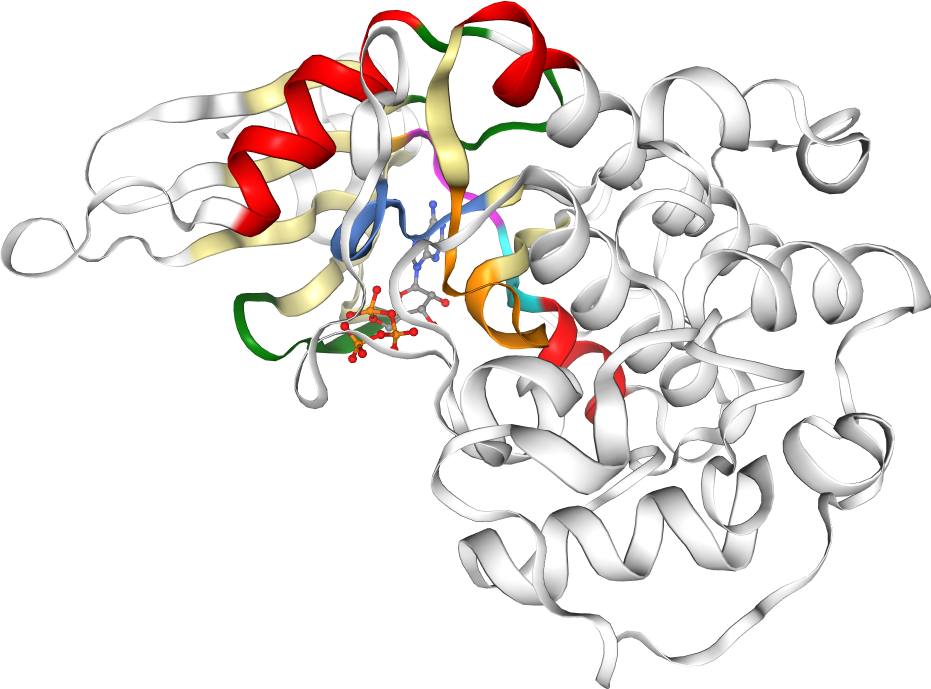

In [12]:
viewer.viewer._display_image()